# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.


# 1. Perkenalan Dataset

Pada proyek *Machine Learning System* ini, dataset yang digunakan adalah **Hotel Booking Demand** dengan rincian sebagai berikut:

* **Nama Dataset:** Hotel Booking Demand
* **Sumber Dataset:** Publik (Kaggle - diunggah oleh Jesse Mostipak)
* **Tautan Referensi:** [Kaggle Hotel Booking Demand](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand)
* **Karakteristik Data:** Terdiri dari puluhan ribu data historis pemesanan hotel (City Hotel dan Resort Hotel), mencakup fitur-fitur seperti waktu pemesanan (*lead time*), jumlah tamu, asal negara, hingga tipe deposit.
* **Tujuan Eksperimen:** Membangun model *binary classification* untuk memprediksi apakah seorang pelanggan akan membatalkan pesanannya atau tidak (berdasarkan kolom target `is_canceled`).

Dataset mentah ini (`hotel_bookings.csv`) telah diunduh secara lokal dan ditempatkan di dalam folder `dataset_raw` untuk mendukung integrasi *pipeline* CI/CD otomatisasi secara aman tanpa harus melakukan *scraping* berulang ke *server* Kaggle.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Konfigurasi visualisasi
sns.set_theme(style="whitegrid")
%matplotlib inline

print("Pustaka core analytics dan preprocessing berhasil dimuat.")

Pustaka core analytics dan preprocessing berhasil dimuat.


# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [ ]:
# Membaca dataset dengan nama file yang konsisten
dataset_path = '/content/hotel_bookings.csv'
df = pd.read_csv(dataset_path)

print(f"Dimensi Dataset Mentah: {df.shape[0]} baris, {df.shape[1]} kolom\n")
print("=== 5 BARIS PERTAMA DATASET ===")
display(df.head())

Dimensi Dataset Mentah: 119390 baris, 32 kolom

=== 5 BARIS PERTAMA DATASET ===


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.0,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.0,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.0,0,1,Check-Out,2015-07-03


# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

In [ ]:
print("=== STRUKTUR DATA DAN TIPE DATA KOLOM ===")
df.info()

print("\n=== MATRIKS STATISTIK DESKRIPTIF DATA NUMERIK ===")
display(df.describe().T)

print("\n=== MATRIKS STATISTIK DESKRIPTIF DATA KATEGORIK ===")
display(df.describe(include=['object']).T)

=== STRUKTUR DATA DAN TIPE DATA KOLOM ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          1193

,count,mean,std,min,25%,50%,75%,max
is_canceled,119390.0,0.370416,0.482918,0.00,0.00,0.000,1.0,1.0
lead_time,119390.0,104.011416,106.863097,0.00,18.00,69.000,160.0,737.0
arrival_date_year,119390.0,2016.156554,0.707476,2015.00,2016.00,2016.000,2017.0,2017.0
arrival_date_week_number,119390.0,27.165173,13.605138,1.00,16.00,28.000,38.0,53.0
arrival_date_day_of_month,119390.0,15.798241,8.780829,1.00,8.00,16.000,23.0,31.0
stays_in_weekend_nights,119390.0,0.927599,0.998613,0.00,0.00,1.000,2.0,19.0
stays_in_week_nights,119390.0,2.500302,1.908286,0.00,1.00,2.000,3.0,50.0
adults,119390.0,1.856403,0.579261,0.00,2.00,2.000,2.0,55.0
children,119386.0,0.103890,0.398561,0.00,0.00,0.000,0.0,10.0
babies,119390.0,0.007949,0.097436,0.00,0.00,0.000,0.0,10.0



=== MATRIKS STATISTIK DESKRIPTIF DATA KATEGORIK ===


,count,unique,top,freq
hotel,119390,2,City Hotel,79330
arrival_date_month,119390,12,August,13877
meal,119390,5,BB,92310
country,118902,177,PRT,48590
market_segment,119390,8,Online TA,56477
distribution_channel,119390,5,TA/TO,97870
reserved_room_type,119390,10,A,85994
assigned_room_type,119390,12,A,74053
deposit_type,119390,3,No Deposit,104641
customer_type,119390,4,Transient,89613


# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

In [ ]:
print("=== ANALISIS MISSING VALUES PER KOLOM ===")
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({'Total Missing': missing_values, 'Persentase (%)': missing_percentage})
display(missing_df[missing_df['Total Missing'] > 0])

print("\n=== ANALISIS DUPLIKASI DATA ===")
duplicate_count = df.duplicated().sum()
print(f"Total baris data duplikat yang terdeteksi: {duplicate_count}")

=== ANALISIS MISSING VALUES PER KOLOM ===


,Total Missing,Persentase (%)
children,4,0.003350
country,488,0.408744
agent,16340,13.686238
company,112593,94.306893



=== ANALISIS DUPLIKASI DATA ===
Total baris data duplikat yang terdeteksi: 31994


/tmp/ipykernel_1412/796124777.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x=target_column, palette='viridis')


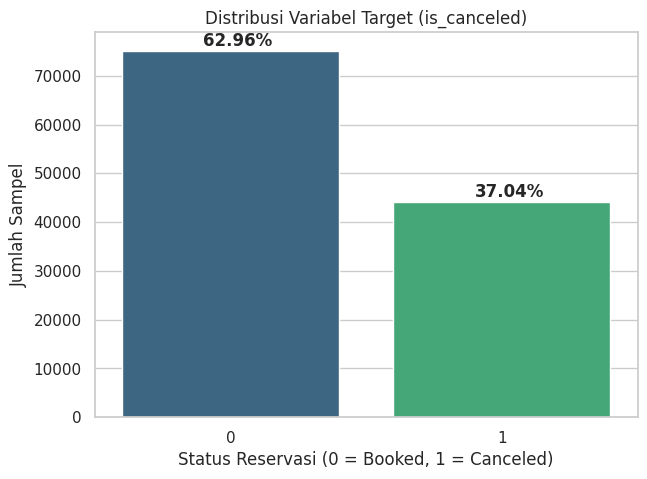

In [ ]:
# Target klasifikasi: 0 (Booked), 1 (Canceled)
target_column = 'is_canceled'

plt.figure(figsize=(7, 5))
ax = sns.countplot(data=df, x=target_column, palette='viridis')
plt.title('Distribusi Variabel Target (is_canceled)')
plt.xlabel('Status Reservasi (0 = Booked, 1 = Canceled)')
plt.ylabel('Jumlah Sampel')

# Labeling persentase
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.2f}%'
    x_pos = p.get_x() + p.get_width() / 2 - 0.1
    y_pos = p.get_height() + 1000
    ax.annotate(percentage, (x_pos, y_pos), fontweight='bold')

plt.show()

In [ ]:
print("=== MEMULAI PROSES PEMBERSIHAN DATA ===")

# 1. Menghapus data duplikat
if df.duplicated().sum() > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("-> Data duplikat berhasil dieliminasi.")

# 2. Imputasi nilai kosong (Missing Values)
df['children'] = df['children'].fillna(0)
df['country'] = df['country'].fillna('Unknown')
df['agent'] = df['agent'].fillna(0)
df['company'] = df['company'].fillna(0)

# 3. Mencegah Data Leakage: Hapus kolom yang bocor/terlalu berkorelasi dengan target masa depan
columns_to_drop = ['reservation_status', 'reservation_status_date']
df_clean = df.drop(columns=columns_to_drop)

print(f"-> Pembersihan selesai. Dimensi data bersih: {df_clean.shape}")

=== MEMULAI PROSES PEMBERSIHAN DATA ===
-> Data duplikat berhasil dieliminasi.
-> Pembersihan selesai. Dimensi data bersih: (87396, 30)


In [ ]:
# Memisahkan matriks fitur (X) dan vektor target (y)
X = df_clean.drop(columns=[target_column])
y = df_clean[target_column]

# Deteksi otomatis kolom dengan tipe data kategorik
categorical_cols = X.select_dtypes(include=['object']).columns
X_encoded = X.copy()

print(f"Mengonversi {len(categorical_cols)} kolom kategorikal menggunakan LabelEncoder...")

for col in categorical_cols:
    le = LabelEncoder()
    X_encoded[col] = le.fit_transform(X_encoded[col].astype(str))

print("-> Proses encoding seluruh fitur kategorikal selesai.")

Mengonversi 10 kolom kategorikal menggunakan LabelEncoder...
-> Proses encoding seluruh fitur kategorikal selesai.


In [ ]:
# Standardisasi variabel menggunakan StandardScaler
scaler = StandardScaler()
X_scaled_array = scaler.fit_transform(X_encoded)

X_scaled = pd.DataFrame(X_scaled_array, columns=X_encoded.columns)

print("=== 5 BARIS PERTAMA HASIL TRANSFORMASI & SCALING FITUR ===")
display(X_scaled.head())

=== 5 BARIS PERTAMA HASIL TRANSFORMASI & SCALING FITUR ===


,hotel,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,assigned_room_type,booking_changes,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,1.25415,3.045939,-1.764027,-0.085051,0.011822,-1.676896,-0.974172,-1.278453,0.198253,-0.304108,...,0.167308,3.751709,-0.111292,-0.736774,-0.203837,-0.074839,-0.105889,-1.932925,-0.29917,-0.839684
1,1.25415,7.636196,-1.764027,-0.085051,0.011822,-1.676896,-0.974172,-1.278453,0.198253,-0.304108,...,0.167308,5.126769,-0.111292,-0.736774,-0.203837,-0.074839,-0.105889,-1.932925,-0.29917,-0.839684
2,1.25415,-0.847064,-1.764027,-0.085051,0.011822,-1.676896,-0.974172,-0.791496,-1.397925,-0.304108,...,0.167308,-0.373470,-0.111292,-0.736774,-0.203837,-0.074839,-0.105889,-0.569627,-0.29917,-0.839684
3,1.25415,-0.777338,-1.764027,-0.085051,0.011822,-1.676896,-0.974172,-0.791496,-1.397925,-0.304108,...,-0.838161,-0.373470,-0.111292,2.028244,-0.203837,-0.074839,-0.105889,-0.569627,-0.29917,-0.839684
4,1.25415,-0.765717,-1.764027,-0.085051,0.011822,-1.676896,-0.974172,-0.304540,0.198253,-0.304108,...,-0.838161,-0.373470,-0.111292,1.446135,-0.203837,-0.074839,-0.105889,-0.151549,-0.29917,0.362324


In [ ]:
# Gabungkan fitur yang sudah diskala dengan label target
df_final = pd.concat([X_scaled, y.reset_index(drop=True)], axis=1)

# Simpan ke dalam file CSV untuk tahapan otomatisasi dan pemodelan
output_path = '/content/hotel_bookings_processed.csv'
df_final.to_csv(output_path, index=False)

print("PROSES EKSPERIMEN REKAYASA DATA SELESAI.")
print(f"File data siap latih telah disimpan secara lokal di: {output_path}")

PROSES EKSPERIMEN REKAYASA DATA SELESAI.
File data siap latih telah disimpan secara lokal di: /content/hotel_bookings_processed.csv
